In [ ]:
from imports import *

In [254]:
(3/2)*(((etaM)*(a**2)*(J))/(r**4))*((3 * (np.sin(np.deg2rad(lat))**2))-1)

array([-0.01591188, -0.01589734, -0.01585374, -0.01578113, -0.0156796 ,
       -0.01554927, -0.01539031, -0.0152029 , -0.01498728, -0.0147437 ,
       -0.01447247, -0.01417392, -0.0138484 , -0.01349631, -0.01311809,
       -0.0127142 , -0.01228512, -0.01183138, -0.01135353, -0.01085216,
       -0.01032787, -0.00978131, -0.00921313, -0.00862404, -0.00801475,
       -0.007386  , -0.00673856, -0.00607321, -0.00539078, -0.00469208,
       -0.00397797, -0.00324932, -0.00250702, -0.00175198, -0.0009851 ,
       -0.00020734,  0.00058038,  0.00137708,  0.00218179,  0.00299354,
        0.00381134,  0.00463418,  0.00546107,  0.006291  ,  0.00712296,
        0.00795594,  0.00878891,  0.00962087,  0.01045081,  0.0112777 ,
        0.01210054,  0.01291834,  0.01373009,  0.0145348 ,  0.0153315 ,
        0.01611921,  0.01689698,  0.01766386,  0.0184189 ,  0.0191612 ,
        0.01988985,  0.02060396,  0.02130265,  0.02198509,  0.02265044,
        0.02329788,  0.02392663,  0.02453592,  0.02512501,  0.02

In [366]:
from matplotlib.ticker import ScalarFormatter

Text(0, 0.5, 'mGal')

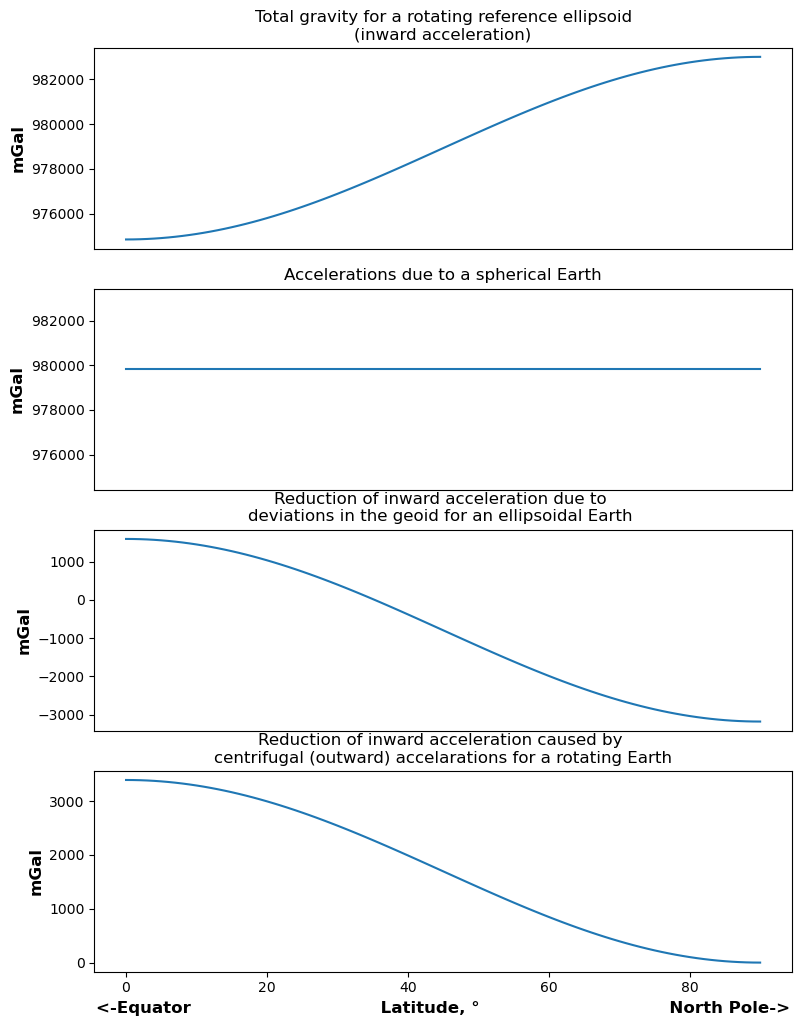

In [369]:
etaM=3.986005e14 # m3/s2
J=0.00108263 #non-dimensional
a=6378.137e3 #/meters
omega=7.292115e-5 #rad/s

latitude=lambda th:np.sin(np.deg2rad(th))

unitscale=1e5

spherical_gravity = lambda r: (etaM/(r**2))
geoid_gravity = lambda lat,r: -((3/2)* ((etaM*(a**2)*J)/(r**4))*(3*(np.sin(np.deg2rad(lat))**2)-1))
centrifugal_acceleration = lambda lat,r: (omega**2)*(r*np.cos(np.deg2rad(lat))**2) 

gravity = lambda lat,r: spherical_gravity(r) - geoid_gravity(lat,r) - centrifugal_acceleration(lat,r)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(False)
fig,axes = plt.subplots(4,1,figsize=(9,12))
axes=axes.reshape(-1)
lat = np.arange(0,90+1,1)
r = a
plat = (lat)
ax=axes[0];ax.plot(plat,gravity(lat,r)*unitscale);ax.set_title('Total gravity for a rotating reference ellipsoid\n(inward acceleration)');ax.set_ylabel('Normal Gravity')
ax.set_xticks([]);ax.set_ylabel('mGal',fontweight='bold',fontsize=12)
ylim=ax.get_ylim()
ax=axes[1];ax.plot(plat,lat*0+spherical_gravity(r)*unitscale);ax.set_title('Accelerations due to a spherical Earth');ax.set_ylabel('Gravity for Earth \nas a perfect sphere')
ax.set_xticks([]);ax.set_ylabel('mGal',fontweight='bold',fontsize=12)
ax.yaxis.set_major_formatter(formatter)
ax.set_ylim(ylim)
ax=axes[2];ax.plot(plat,geoid_gravity(lat,r)*unitscale);ax.set_title('Reduction of inward acceleration due to \ndeviations in the geoid for an ellipsoidal Earth ')

# ax.axhline(geoid_gravity(35.26,r),linestyle=':')
# ax.axvline(35.26,linestyle=':')

ax.set_xticks([]);ax.set_ylabel('mGal',fontweight='bold',fontsize=12)
ax=axes[3];ax.plot(plat,centrifugal_acceleration(lat,r)*unitscale);ax.set_title('Reduction of inward acceleration caused by \ncentrifugal (outward) accelarations for a rotating Earth')
ax.set_xlabel('<-Equator                                 Latitude, °                                 North Pole->',fontweight='bold',fontsize=12);ax.set_ylabel('mGal',fontweight='bold',fontsize=12)
# _=ax.set_xticks(np.arange(0,91,10))
# fig.legend()



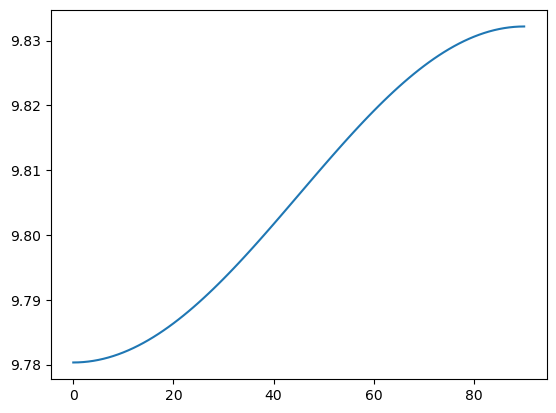

In [324]:
wgs84 = lambda lat:(9.7803267714)*((1+0.00193185138639*(np.sin(np.deg2rad(lat))**2))/ ((1-0.00669437999013*(np.sin(np.deg2rad(lat))**2))**0.5))

plt.plot(lat,wgs84(lat))

In [325]:
mass_observer=50e3
ilat=21.25;print(f'Hawaii: {gravity(ilat,r_ellipsoid(ilat))}')
hawaii_g=gravity(ilat,r_ellipsoid(ilat))
ilat=53;print(f'London: {gravity(ilat,r_ellipsoid(ilat))}')
london_g=gravity(ilat,r_ellipsoid(ilat))

frac=-((hawaii_g-london_g)/hawaii_g)
lighter=(mass_observer - ((1-frac)*mass_observer))
print(' ')
print(f'A person from Hawaii weighs about {np.round(frac*100,3)}% less in London. \n\nSo, about {int(lighter)} grams less for a {int(m_centg_ratio/1000)}kg individual.')

Hawaii: 9.79691953345298
London: 9.884316176936629
 
A person from Hawaii weighs about 0.892% less in London. 

So, about 446 grams less for a 0kg individual.


Hawaii: 9.781490235266947
London: 9.7861443536116
 
A person from Hawaii weighs about 0.048% more in London. 

So, about 23 grams less for a 50kg individual.


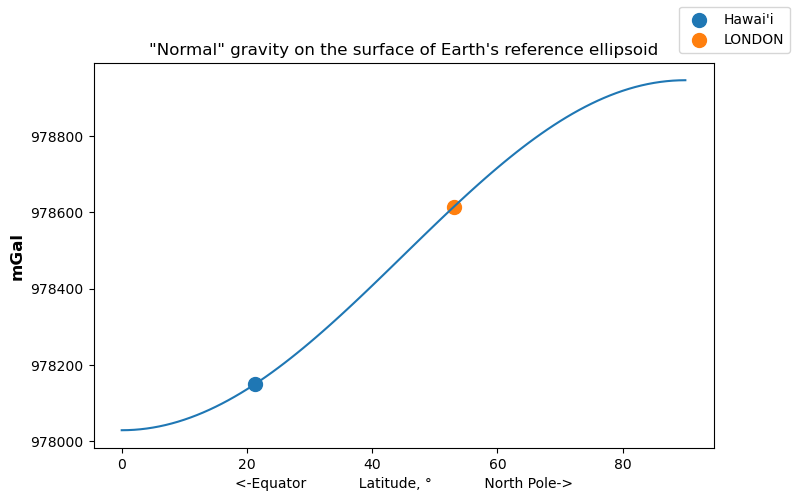

In [371]:
etaM=3.986005e14 # m3/s2
J=0.00108263 #non-dimensional
a=6378.137e3 #/meters
omega=7.292115e-5 #rad/s

m_centg_ratio = ((omega**2)*(a**3))/etaM
f=0.00530
latitude=lambda th:np.sin(np.deg2rad(th))

surface_gravity = lambda lat: \
(etaM/(a**2))*\
(1+(3/2)*J-m_centg_ratio)+\
(2*f - (9/2)*J + m_centg_ratio)* (np.sin(np.deg2rad(lat))**2)

spherical_gravity = lambda r: (etaM/(r**2))-(3/2)
geoid_gravity = lambda lat,r: ((etaM*(a**2)*J)/(r**4))*(3*(np.sin(np.deg2rad(lat))**2)-1)
centrifugal_acceleration = lambda lat,r: (omega**2)*(r*np.cos(np.deg2rad(lat))**2) 
r_ellipsoid = lambda lat:a*(1-f*np.sin(np.deg2rad(lat)))
# surface_gravity(0)

fig,axes = plt.subplots(1,1,figsize=(8,5))
# axes=axes.reshape(-1)
lat = np.arange(0,90+1,1)
r = a
ax=axes;ax.plot(lat,surface_gravity(lat)*1e5);ax.set_title(f'"Normal" gravity on the surface of Earth\'s reference ellipsoid');ax.set_ylabel('Normal Gravity')
# ax.set_xticks([])
ax.set_ylabel('mGal',fontweight='bold',fontsize=12)
ax.set_xlabel('<-Equator            Latitude, °            North Pole->')
# ax.set_ylabel('m/$s^{2}$')

ilat=21.25;print(f'Hawaii: {surface_gravity(ilat)}')
hawaii_g=surface_gravity(ilat)
ilat=53;print(f'London: {surface_gravity(ilat)}')
london_g=surface_gravity(ilat)

mass_observer=50e3
frac=-((hawaii_g-london_g)/hawaii_g)
lighter=frac*mass_observer
print(' ')
print(f'A person from Hawaii weighs about {np.round(frac*100,3)}% more in London. \n\nSo, about {int(lighter)} grams less for a {int(mass_observer/1000)}kg individual.')

ax.scatter(21.25,hawaii_g*1e5,label='Hawai\'i',s=100)
ax.scatter(53,london_g*1e5 ,label='LONDON',s=100)
fig.legend()

In [341]:
ilat=21.25;print(f'Hawaii: {surface_gravity(ilat)}')
hawaii_g=surface_gravity(ilat)
ilat=53;print(f'London: {surface_gravity(ilat)}')
london_g=surface_gravity(ilat)

mass_observer=50e3
frac=-((hawaii_g-london_g)/hawaii_g)
lighter=frac*mass_observer
print(' ')
print(f'A person from Hawaii weighs about {np.round(frac*100,3)}% less in London. \n\nSo, about {int(lighter)} grams less for a {int(mass_observer/1000)}kg individual.')

Hawaii: 9.781490235266947
London: 9.7861443536116
 
A person from Hawaii weighs about 0.048% less in London. 

So, about 23 grams less for a 50kg individual.


Text(0, 0.5, 'g (mGal)')

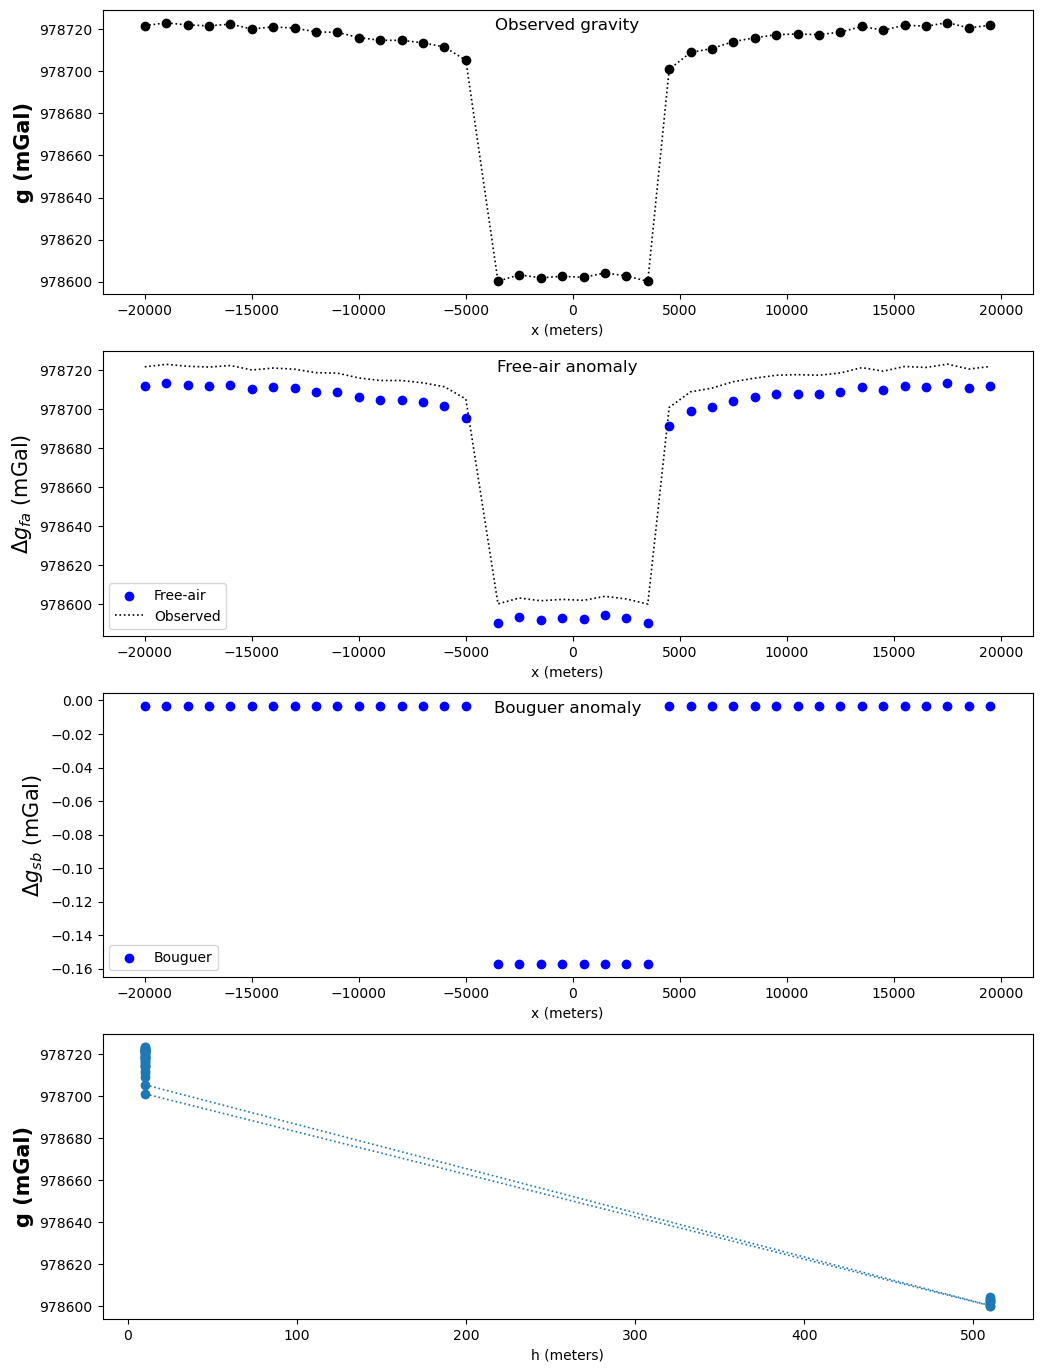

In [443]:
wgs84 = lambda lat:(9.7803267714)*((1+0.00193185138639*(np.sin(np.deg2rad(lat))**2))/ ((1-0.00669437999013*(np.sin(np.deg2rad(lat))**2))**0.5))
lat=21.5
g0=wgs84(lat)
G = 6.67430e-11

gsb = lambda rho,h: (2*np.pi*G*rho*(h))

free_air_corrected = lambda g,h: g-((-0.3086e-3)*(h))-g0
bouguer_corrected = lambda g,h,rho: g-(free_air_corrected(g,h))-gsb(rho,h)-g0
data=np.loadtxt('/Users/charlesh/Downloads/data.hw6.txt')
x,h,g = data.T
fig,axes = plt.subplots(nrows=4,ncols=1,figsize=(12,17))
ax=axes[0]
ax.plot(x,g,linestyle=':',linewidth=1.2,color='k')
ax.scatter(x,g,color='k')
ax.set_xlabel('x (meters)')
ax.set_ylabel('g (mGal)',fontweight='bold',fontsize=15)
ax.set_title('Observed gravity',y=0.9)
ax=axes[1]
# ax.plot(x,free_air_corrected(g,h),linestyle=':',linewidth=1.2,label=None,color='blue')
ax.scatter(x,free_air_corrected(g,h),label='Free-air',color='blue')
ax.plot(x,g,label='Observed',color='k',linestyle=':',linewidth=1.2)
ax.legend()
ax.set_xlabel('x (meters)')
ax.set_ylabel('$\Delta g_{fa}$ (mGal)',fontsize=15)
ax.set_title('Free-air anomaly',y=0.9)


rho = 2600/1000
ax=axes[2]
# ax.plot(x,free_air_corrected(g,h),linestyle=':',linewidth=1.2,label=None,color='blue')
ax.scatter(x,bouguer_corrected(g,h,rho),label='Bouguer',color='blue')
# ax.plot(x,g,label='Observed',color='k',linestyle=':',linewidth=1.2)
ax.legend()
ax.set_xlabel('x (meters)')
ax.set_ylabel('$\Delta g_{sb}$ (mGal)',fontsize=15)
ax.set_title('Bouguer anomaly',y=0.9)


ax=axes[3]
ax.plot(h,g,linestyle=':',linewidth=1.2)
ax.scatter(h,g)
ax.set_xlabel('h (meters)')
ax.set_ylabel('g (mGal)',fontweight='bold',fontsize=15)

Text(0, 0.5, 'h (meters)')

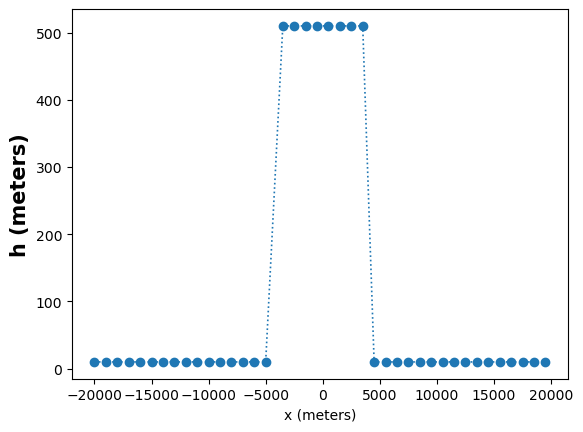

In [398]:
plt.plot(x,h,linestyle=':',linewidth=1.2)
plt.scatter(x,h)
plt.xlabel('x (meters)')
plt.ylabel('h (meters)',fontweight='bold',fontsize=15)